## Basic Setup 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('cleaned_GlobalweatherRepository.csv')  # Replace 'data.csv' with your actual file path
df['date'] = pd.to_datetime(df['last_updated_dt'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.to_period('Q')
df['season'] = df['month'] % 12 // 3 + 1   # 1–4 seasons

C:\Users\adity\AppData\Local\Temp\ipykernel_10508\17563515.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['last_updated_dt'])


## Filters

### Latitude & Longitude wise

In [6]:
df_latlon = df[(df['latitude'].between(20, 30)) & (df['longitude'].between(70, 85))]


### Country Wise

In [7]:
df_country = df[df['country'] == 'India']

In [18]:
df_timezone = df[df['timezone'] == 'Asia/Kabul']
print(df_timezone.head(5))

         country location_name  latitude  longitude    timezone  \
0    afghanistan         kabul     34.52      69.18  Asia/Kabul   
195  afghanistan         kabul     34.52      69.18  Asia/Kabul   
390  afghanistan         kabul     34.52      69.18  Asia/Kabul   
583  afghanistan         kabul     34.52      69.18  Asia/Kabul   
776  afghanistan         kabul     34.52      69.18  Asia/Kabul   

     last_updated_epoch      last_updated  temperature_celsius  \
0            1715849100  16-05-2024 13:15                 26.6   
195          1715868000  16-05-2024 18:30                 22.0   
390          1715961600  17-05-2024 20:30                 15.0   
583          1716042600  18-05-2024 19:00                 19.5   
776          1716127200  19-05-2024 18:30                 16.9   

         condition_text  wind_kph  ...  moonrise  moonset      moon_phase  \
0         partly cloudy      13.3  ...  12:12 PM  1:11 AM  Waxing Gibbous   
195  patchy rain nearby       7.2  ...  12:12 

## Time Based Analysis

### Yearwise

In [25]:
# aggregate using actual column names in the dataframe
yearly = df.groupby('year').agg({
    'temperature_celsius': ['mean', 'min', 'max'],
    'precip_mm': ['mean', 'min', 'max'],
    'wind_kph': 'mean'
})
print(yearly.head(5))

     temperature_celsius             precip_mm               wind_kph
                    mean   min   max      mean  min    max       mean
year                                                                 
2024           23.611792 -24.2  49.2  0.147433  0.0  42.24  13.392089
2025           21.189011 -24.9  48.8  0.133168  0.0  27.40  12.810324
2026           14.979017 -29.8  39.1  0.114364  0.0  11.41  12.411482


### Month wise

In [28]:
monthly = df.groupby('month')['temperature_celsius'].mean()
print(monthly.head(5))

month
1    16.071034
2    16.891252
3    20.095299
4    21.965060
5    23.959537
Name: temperature_celsius, dtype: float64


### Quater-wise

In [30]:
quarterly = df.groupby('quarter')['precip_mm'].sum()
print(quarterly.head(5))

quarter
2024Q2    1442.36
2024Q3    2895.76
2024Q4    2218.06
2025Q1    2145.71
2025Q2    2363.42
Freq: Q-DEC, Name: precip_mm, dtype: float64


### Season-wise

In [32]:
seasonal = df.groupby('season').agg({
    'temperature_celsius': 'mean',
    'precip_mm': 'mean'
})
print(seasonal.head(5))

        temperature_celsius  precip_mm
season                                
1                 16.627349   0.114502
2                 22.310227   0.140184
3                 25.823580   0.153476
4                 21.584752   0.138978


## Temperature Analysis

### AVG Range of temperature

In [33]:
df['temp_range'] = df['temperature_celsius'].max() - df['temperature_celsius'].min()
print(df['temp_range'].head(5))

0    79.0
1    79.0
2    79.0
3    79.0
4    79.0
Name: temp_range, dtype: float64


### Standard Deviation

In [34]:
df['temperature_celsius'].std()

9.556758156409124


### Temperature Anomaly

In [37]:
df['temp_anomaly'] = df['temperature_celsius'] - df['temperature_celsius'].mean()
print(df['temp_anomaly'].head(5))

0     4.950745
1    -2.649255
2     1.350745
3   -15.349255
4     4.350745
Name: temp_anomaly, dtype: float64


### Rolling AVG

In [39]:
df['temp_rolling_7'] = df['temperature_celsius'].rolling(7).mean()
print(df['temp_rolling_7'].head(10))

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
5          NaN
6    19.271429
7    18.185714
8    16.757143
9    15.757143
Name: temp_rolling_7, dtype: float64


## Rain Pattern (Precipitation)

### Total Rainfall

In [40]:
total_rain = df['precip_mm'].sum()
print(f'Total Rainfall: {total_rain} mm')

Total Rainfall: 16959.56 mm


### Rainy Days Count

In [42]:
rainy_days = (df['precip_mm'] > 0).sum()
print(f'Number of Rainy Days: {rainy_days}')

Number of Rainy Days: 41519


### Heavy Rainfall Events

In [44]:
heavy_rain = df[df['precip_mm'] > df['precip_mm'].quantile(0.95)]
print(heavy_rain.head(5))

              country location_name  latitude  longitude  \
103          malaysia  kuala lumpur      3.17     101.70   
135  papua new guinea  port moresby     -9.46     147.19   
156         singapore     singapore      1.29     103.86   
165         sri lanka       colombo      6.93      79.85   
176             tonga    nuku`aloia    -21.13    -175.20   

                 timezone  last_updated_epoch      last_updated  \
103     Asia/Kuala_Lumpur          1715849100  16-05-2024 16:45   
135  Pacific/Port_Moresby          1715849100  16-05-2024 18:45   
156        Asia/Singapore          1715849100  16-05-2024 16:45   
165          Asia/Colombo          1715849100  16-05-2024 14:15   
176     Pacific/Tongatapu          1715849100  16-05-2024 21:45   

     temperature_celsius                       condition_text  wind_kph  ...  \
103                 29.0                        partly cloudy      11.2  ...   
135                 26.2                    light rain shower      15.8  ...

### Dry Spell Duration

In [46]:
df['dry'] = df['precip_mm'] == 0
print(df['dry'].head(5))

0     True
1    False
2     True
3    False
4     True
Name: dry, dtype: bool


## Wind Pattern

### Average & Max Wind Speed 

In [49]:
df['wind_kph'].mean()
df['wind_kph'].max()
print(df['wind_kph'].mean())

12.993026845312171


In [51]:
df['wind_kph'].std()

np.float64(11.881434275650498)

## Anomaly & Extreme Event Detection

### Heatwave Days

In [53]:
heatwave_days = df[df['temperature_celsius'] > df['temperature_celsius'].quantile(0.95)]
print(heatwave_days.head(5))

       country location_name  latitude  longitude         timezone  \
12     bahrain        manama     26.24      50.58     Asia/Bahrain   
13  bangladesh         dhaka     23.72      90.41       Asia/Dhaka   
30    cambodia    phnom penh     11.55     104.92  Asia/Phnom_Penh   
34        chad     n'djamena     12.11      15.05    Africa/Douala   
77       india     new delhi     28.60      77.20     Asia/Kolkata   

    last_updated_epoch      last_updated  temperature_celsius condition_text  \
12          1715849100  16-05-2024 11:45                 36.0          sunny   
13          1715849100  16-05-2024 14:45                 38.4  partly cloudy   
30          1715849100  16-05-2024 15:45                 38.0  partly cloudy   
34          1715849100  16-05-2024 09:45                 37.2          sunny   
77          1715849100  16-05-2024 14:15                 42.0           mist   

    wind_kph  ...   last_updated_dt                date  year  month  quarter  \
12      22.0  ...

### Cold Wave Days

In [54]:
coldwave_days = df[df['temperature_celsius'] < df['temperature_celsius'].quantile(0.05)]
print(coldwave_days.head(5))


       country location_name  latitude  longitude          timezone  \
35       chile      santiago    -33.45     -70.67  America/Santiago   
230      chile      santiago    -33.45     -70.67  America/Santiago   
784  australia      canberra    -35.28     149.22  Australia/Sydney   
811      chile      santiago    -33.45     -70.67  America/Santiago   
979  australia      canberra    -35.28     149.22  Australia/Sydney   

     last_updated_epoch      last_updated  temperature_celsius condition_text  \
35           1715849100  16-05-2024 04:45                  1.0          clear   
230          1715868000  16-05-2024 10:00                  2.0          sunny   
784          1716127200  20-05-2024 00:00                 -1.0          clear   
811          1716127200  19-05-2024 10:00                  3.0           mist   
979          1716216300  21-05-2024 00:45                  3.0          clear   

     wind_kph  ...   last_updated_dt                date  year  month  \
35        6.8

## Correlation Analysis

### Correlation Matrix

In [57]:
corr = df[['temperature_celsius', 'precip_mm', 'wind_kph']].corr()

### Heatmap

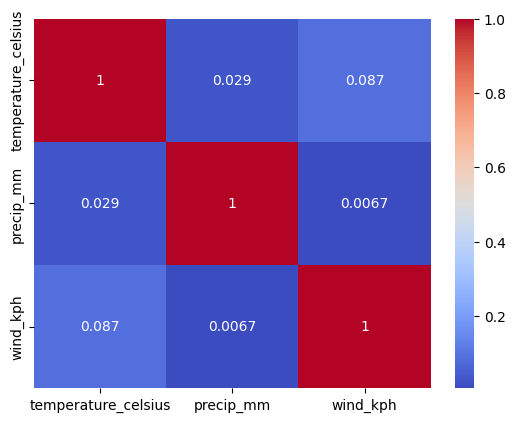

In [58]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

## Visualizations

### Line Chart (Trend)

In [ ]:
plt.figure(figsize=(12, 6))
df_2024 = df[df['year'] == 2024]
plt.plot(df_2024['date'], df_2024['temperature_celsius'])
plt.title('Temperature Trend in 2024')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

AttributeError: Can only use .str accessor with string values!